In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Create customer transaction dataset
np.random.seed(42)
n_customers = 50

df = pd.DataFrame({
    'customer_id'   : [f'C{i:03d}' for i in range(1, n_customers+1)],
    'last_purchase' : pd.date_range('2024-01-01', '2024-12-31', periods=n_customers),
    'frequency'     : np.random.randint(1, 30, n_customers),
    'monetary'      : np.round(np.random.exponential(5000, n_customers) + 500, 2)
})

# Calculate Recency (days since last purchase)
today = pd.Timestamp('2024-12-31')
df['recency'] = (today - df['last_purchase']).dt.days

print(df.head())

  customer_id                 last_purchase  frequency  monetary  recency
0        C001 2024-01-01 00:00:00.000000000          7    737.82      365
1        C002 2024-01-08 10:46:31.836734693         20   5176.67      357
2        C003 2024-01-15 21:33:03.673469387         29   1434.81      350
3        C004 2024-01-23 08:19:35.510204081         15    836.32      342
4        C005 2024-01-30 19:06:07.346938775         11  15368.44      335


In [ ]:
# ══════════════════════════════════════
# RFM SCORING
# Convert raw numbers into 1-5 scores
# ══════════════════════════════════════

# Score each metric 1-5 (5 = best)
df['R_score'] = pd.qcut(df['recency'], 5, labels=[5,4,3,2,1])
df['F_score'] = pd.qcut(df['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
df['M_score'] = pd.qcut(df['monetary'], 5, labels=[1,2,3,4,5])

df['RFM_score'] = (df['R_score'].astype(int) +
                    df['F_score'].astype(int) +
                    df['M_score'].astype(int))

print(df[['customer_id','recency','frequency','monetary','RFM_score']].head(10))

  customer_id  recency  frequency  monetary  RFM_score
0        C001      365          7    737.82          3
1        C002      357         20   5176.67          8
2        C003      350         29   1434.81          8
3        C004      342         15    836.32          4
4        C005      335         11  15368.44          8
5        C006      327          8  17353.15          7
6        C007      320         29   8761.66         10
7        C008      312         21   2316.44          6
8        C009      305          7   1013.89          3
9        C010      297         26   6263.75         10


In [ ]:

# ══════════════════════════════════════
# SEGMENT CUSTOMERS
# ══════════════════════════════════════

def segment(score):
    if score >= 12:
        return 'Champion'
    elif score >= 9:
        return 'Loyal'
    elif score >= 6:
        return 'At Risk'
    else:
        return 'Lost'

df['Segment'] = df['RFM_score'].apply(segment)

print(df['Segment'].value_counts())

Segment
Loyal       19
At Risk     15
Champion    10
Lost         6
Name: count, dtype: int64


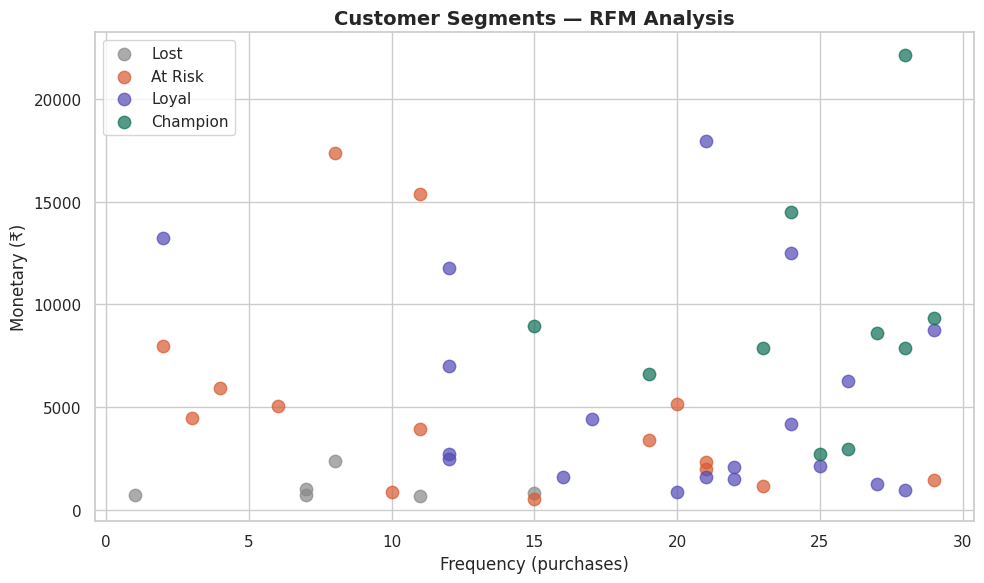

RFM Segmentation done ✅


In [ ]:
# ══════════════════════════════════════
# VISUALIZE SEGMENTS
# ══════════════════════════════════════

plt.figure(figsize=(10, 6))
colors = {'Champion':'#0F6E56','Loyal':'#534AB7',
          'At Risk':'#D85A30','Lost':'#888888'}

for seg in df['Segment'].unique():
    seg_data = df[df['Segment'] == seg]
    plt.scatter(seg_data['frequency'], seg_data['monetary'],
                label=seg, color=colors.get(seg), s=80, alpha=0.7)

plt.title('Customer Segments — RFM Analysis',
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency (purchases)')
plt.ylabel('Monetary (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150)
plt.show()

print("RFM Segmentation done ✅")

In [ ]:
# ══════════════════════════════════════
# BUSINESS INSIGHTS
# ══════════════════════════════════════

print("=" * 50)
print("   RFM SEGMENTATION INSIGHTS")
print("=" * 50)

for seg in ['Champion','Loyal','At Risk','Lost']:
    seg_data = df[df['Segment'] == seg]
    print(f"\n{seg}: {len(seg_data)} customers")
    print(f"  Avg spend: ₹{seg_data['monetary'].mean():,.0f}")
    print(f"  Action: ", end="")
    if seg == 'Champion':
        print("Reward with loyalty perks")
    elif seg == 'Loyal':
        print("Upsell premium products")
    elif seg == 'At Risk':
        print("Send win-back campaign")
    else:
        print("Re-engagement email or let go")

   RFM SEGMENTATION INSIGHTS

Champion: 10 customers
  Avg spend: ₹9,166
  Action: Reward with loyalty perks

Loyal: 19 customers
  Avg spend: ₹5,439
  Action: Upsell premium products

At Risk: 15 customers
  Avg spend: ₹5,129
  Action: Send win-back campaign

Lost: 6 customers
  Avg spend: ₹1,060
  Action: Re-engagement email or let go
